In [1]:
import numpy as np
import poisson_equation
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [10]:
def plot_potential(potential_data, N):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y)

    data = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            data[i][j] = potential_data[i * N + j]
    
    fig = go.Figure()    

    fig.add_trace(go.Surface(z=data, x=X, y=Y, colorscale="YlGnBu"))

    fig.update_layout(
        title="3D График потенциала",
        width=1000,  
        height=800, 
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Potential",
        ),
    )
    fig.show()
    
def compute_deviation(result, U_exact_solution):
    result = np.array(result)  
    error = np.sqrt(np.sum((result - U_exact_solution) ** 2))
    return error

# Аналитиеское решение

In [97]:
def U_analit_function(x, y):
    value = 0
    for k in range(100):
        coef = np.pi * (2 * k + 1)
        value += np.sin(coef * x) * np.sinh(coef * y) / (np.sinh(coef) * coef)
    return 4 * value

def U_list_analit(N, terms = 100):
    data_result = np.zeros(N * N)
    for i in range(N):
        for j in range(terms):
            x = i / (N - 1)  
            y = j / (N - 1)
            data_result[i * N + j] = U_analit_function(x, y)
    return data_result


In [98]:
nod_number = 100
U_analit = U_list_analit(nod_number)
plot_potential(U_analit, nod_number)

# 3D графики потенциалов

In [103]:
all_solvers = ['Solver_Jacobi', "Solver_Gauss", "Solver_over_relaxation"]
nod_number = 100
iteration = 1000
precision = 0.01
boundary_conditions = np.zeros(nod_number * 4)
source = np.zeros(nod_number ** 2)

for i in range(nod_number):
    boundary_conditions[i] = 0.0
    boundary_conditions[i + 2*nod_number] = 0.0
    boundary_conditions[i + 1*nod_number] = 1.0
    boundary_conditions[i + 3*nod_number] = 0.0


## Метод Якоби

In [104]:
result = poisson_equation.potential_result(
                        all_solvers[0], boundary_conditions, 
                        source, nod_number, 
                        iteration, precision)
plot_potential(result, nod_number)

## Метод Гаусса

In [105]:
result = poisson_equation.potential_result(
                        all_solvers[1], boundary_conditions, 
                        source, nod_number, 
                        iteration, precision)
plot_potential(result, nod_number)

## Метод сверхрелаксации

In [157]:
result = poisson_equation.potential_result(
                        all_solvers[2], boundary_conditions, 
                        source, nod_number, 
                        iteration, precision, omega = 1.9)
plot_potential(result, nod_number)

In [120]:
def copmare_omega(omega_min, omega_max):
    data_omega = []
    delta_omega = 0.005
    iteration = 1000
    precision = 0.01
    for omega in np.linspace(omega_min, omega_max, int(np.round((omega_max - omega_min)/delta_omega))):
        result = poisson_equation.potential_result(
                            all_solvers[2], boundary_conditions, 
                            source, nod_number, 
                            iteration, precision, omega)
        data_omega.append(compute_deviation(result, U_analit))

    plt.figure(figsize=(10, 6)) 
    ymin = min(data_omega)
    ymax = data_omega[0]
    plt.ylim(ymin, ymax)
    
    plt.plot(np.linspace(omega_min, omega_max, int(np.round((omega_max - omega_min)/delta_omega))), data_omega)

    plt.xlabel('Omega')
    plt.ylabel('Error')
    plt.grid(True)
    plt.show()
        

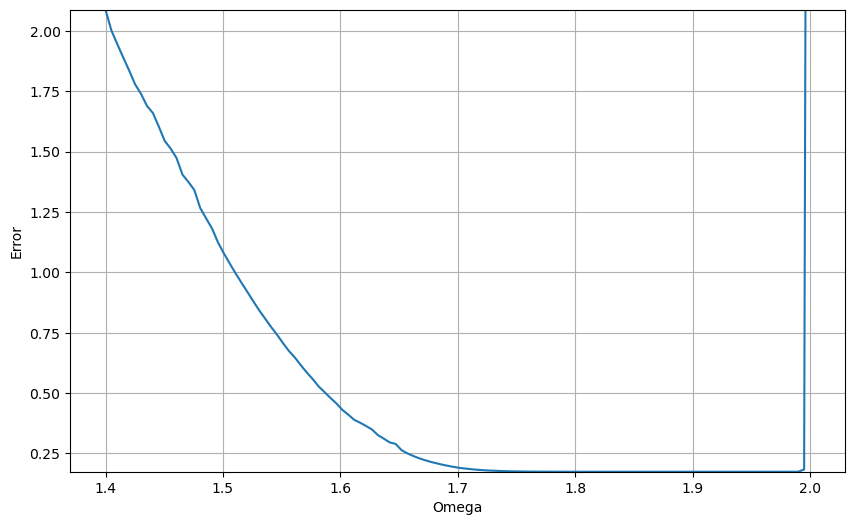

In [121]:
copmare_omega(1.4, 2.0)

In [152]:
omega_optimal = 1.97

# Сравнение методов

In [153]:
def compare_methods(N_max, delta_N, U_exact_solution, omega_values):
    nod_number = 100
    precision = 0.01
    boundary_conditions = np.zeros(nod_number * 4)
    source = np.zeros(nod_number ** 2)
    
    for i in range(nod_number):
        boundary_conditions[i] = 0.0
        boundary_conditions[i + 1 * nod_number] = 1.0
        boundary_conditions[i + 2 * nod_number] = 0.0
        boundary_conditions[i + 3 * nod_number] = 0.0
    
    solvers = ["Solver_Jacobi", "Solver_Gauss"] + [f"Solver_over_relaxation_omega_{w}" for w in omega_values]
    solver_map = {solver: ("Solver_over_relaxation" if "over_relaxation" in solver else solver) for solver in solvers}
    deviations = {solver: [] for solver in solvers}
    iterations = {solver: [] for solver in solvers}
    
    labels = ["Jacobi", "Gauss"] + [f"Over Relaxation omega = {w}" for w in omega_values]

    for solver_name in solvers:
        iteration = 0
        omega = float(solver_name.split("_")[-1]) if "over_relaxation" in solver_name else 1

        while iteration < N_max:
            result = poisson_equation.potential_result(
                solver_map[solver_name], boundary_conditions, 
                source, nod_number, 
                iteration, precision, omega
            )
            deviation = compute_deviation(result, U_exact_solution)
            deviations[solver_name].append(deviation)
            iterations[solver_name].append(iteration)
            iteration += delta_N
    
    plt.figure(figsize=(10, 6)) 
    for solver_name, label in zip(solvers, labels):
        plt.plot(iterations[solver_name], deviations[solver_name], label=label)
    
    plt.xlabel('Number of Iterations')
    plt.ylabel('Error')
    plt.title('Convergence of the Solvers')
    plt.legend()
    plt.grid(True)
    plt.show()


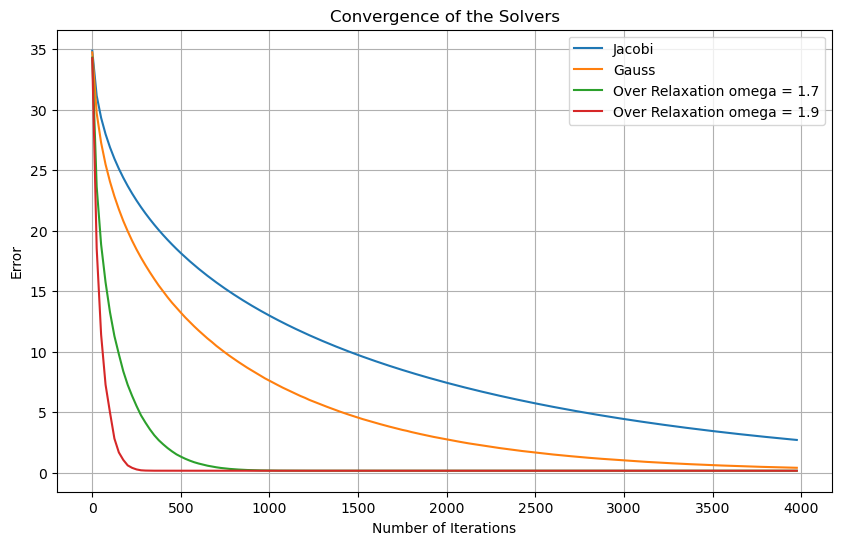

In [156]:
N_max = 4000
delta_N = 25
omega_values = [1.7, 1.90]
compare_methods(N_max, delta_N, U_analit, omega_values)

# Задание 5

In [158]:
all_solvers = ['Solver_Jacobi', "Solver_Gauss", "Solver_over_relaxation"]
nod_number = 100
iteration = 1000
precision = 0.01
omega = 1.5
boundary_conditions = np.zeros(nod_number * 4)
source = np.zeros(nod_number ** 2)

for i in range(nod_number):
    boundary_conditions[i] = 1.0
    boundary_conditions[i + 1*nod_number] = 0.0
    boundary_conditions[i + 2*nod_number] = -1.0
    boundary_conditions[i + 3*nod_number] = 0.0


In [159]:
result = poisson_equation.potential_result(
                        all_solvers[2], boundary_conditions, 
                        source, nod_number, 
                        iteration, precision, omega)
plot_potential(result, nod_number)